<a href="https://colab.research.google.com/github/Ashuralotus/AI_MachineLearning_and_DeepLearning/blob/main/Network_Anomali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [4]:
# Membaca dataset
df = pd.read_csv('/content/network_dataset.csv')

# Menampilkan 5 data pertama
print(df.head())

             timestamp  bandwidth  throughput  congestion  packet_loss  \
0  2024-05-11 12:00:15          2        2.15        0.38          0.0   
1  2024-05-11 12:00:43          2        2.16        0.12          0.0   
2  2024-05-11 12:01:12          2        2.00        0.08          0.0   
3  2024-05-11 12:01:40          2        2.07        0.07          0.0   
4  2024-05-11 12:02:08          2        2.40        0.08          0.0   

   latency  jitter  Routers Planned route Network measure Network target  \
0     6.58    0.52  up xrv6   Best effort              S1             S2   
1     5.36    0.34  up xrv6   Best effort              S1             S2   
2     6.29    0.23  up xrv6   Best effort              S1             S2   
3     5.91    0.51  up xrv6   Best effort              S1             S2   
4     5.81    0.71  up xrv6   Best effort              S1             S2   

  Video target  Percentage video occupancy  Bitrate video  Number videos  
0          NaN         

In [5]:
print(df.columns)

Index(['timestamp', 'bandwidth', 'throughput', 'congestion', 'packet_loss',
       'latency', 'jitter', 'Routers', 'Planned route', 'Network measure',
       'Network target', 'Video target', 'Percentage video occupancy',
       'Bitrate video', 'Number videos'],
      dtype='object')


In [6]:
# Membuat label status jaringan

df['status'] = df.apply(
    lambda row: 'gangguan'
    if row['latency'] > 70 or row['packet_loss'] > 5
    else 'normal',
    axis=1
)

# Melihat hasil
print(df[['latency', 'packet_loss', 'status']].head())

   latency  packet_loss  status
0     6.58          0.0  normal
1     5.36          0.0  normal
2     6.29          0.0  normal
3     5.91          0.0  normal
4     5.81          0.0  normal


In [7]:
# Feature AI
X = df[['bandwidth',
        'throughput',
        'congestion',
        'packet_loss',
        'latency',
        'jitter']]

# Target AI
y = df['status']

In [8]:
# Membagi data training dan testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Split data berhasil")

Split data berhasil


In [9]:
# Membuat model AI
model = DecisionTreeClassifier()

In [10]:
# Training AI
model.fit(X_train, y_train)

print("AI berhasil dilatih")

AI berhasil dilatih


In [11]:
# Data baru
new_data = pd.DataFrame({
    'bandwidth': [900],
    'throughput': [850],
    'congestion': [80],
    'packet_loss': [9],
    'latency': [90],
    'jitter': [30]
})

# Prediksi
prediction = model.predict(new_data)

print("Hasil Prediksi:", prediction[0])

Hasil Prediksi: gangguan


In [12]:
# Prediksi testing
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy AI:", accuracy)

Accuracy AI: 1.0


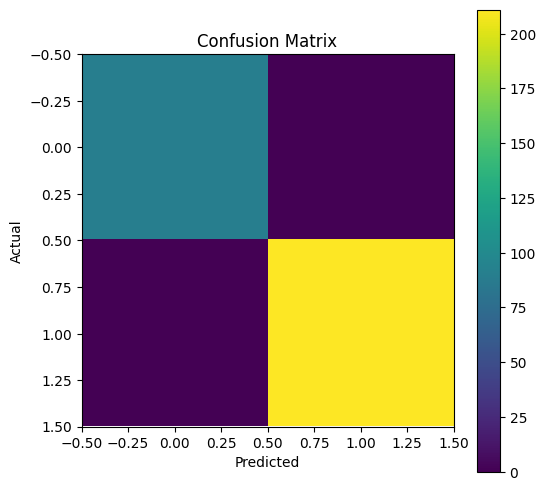

In [13]:
# Membuat confusion matrix

cm = confusion_matrix(y_test, y_pred)

# Visualisasi confusion matrix

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.colorbar()

plt.show()

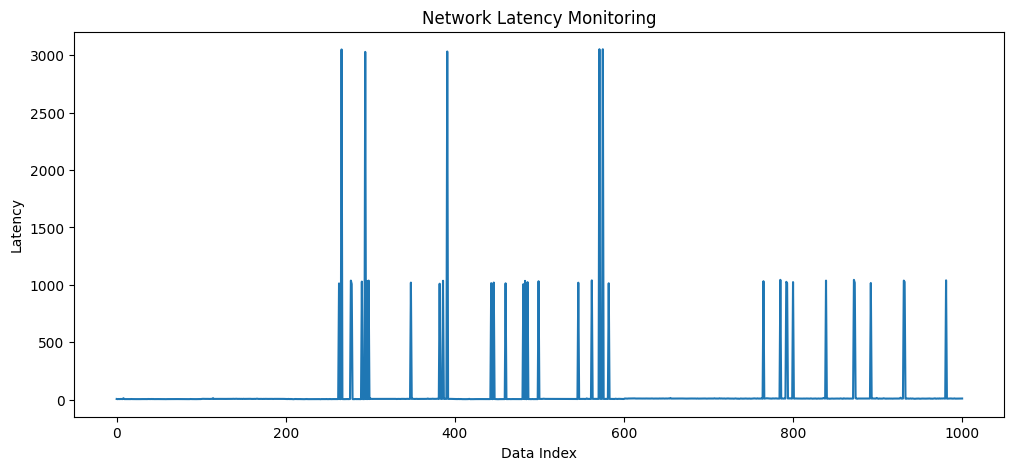

In [14]:
plt.figure(figsize=(12,5))

plt.plot(df['latency'])

plt.title('Network Latency Monitoring')

plt.xlabel('Data Index')

plt.ylabel('Latency')

plt.show()

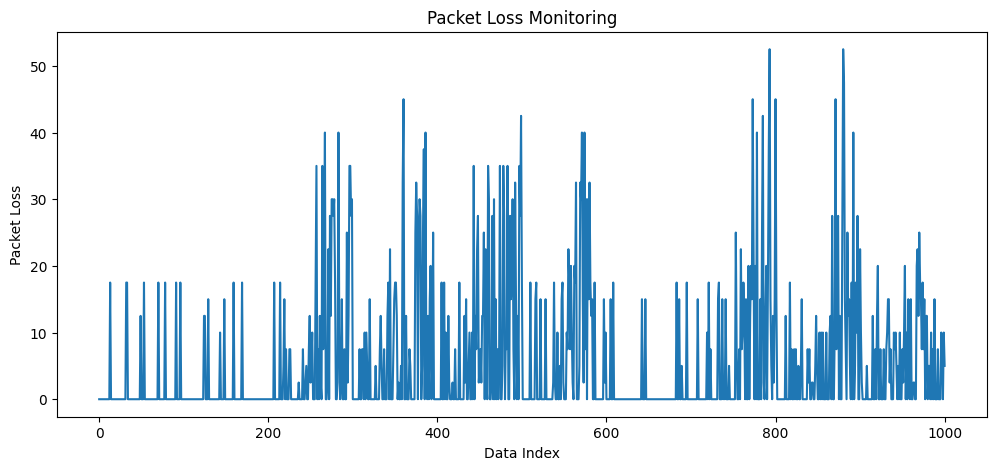

In [15]:
plt.figure(figsize=(12,5))

plt.plot(df['packet_loss'])

plt.title('Packet Loss Monitoring')

plt.xlabel('Data Index')

plt.ylabel('Packet Loss')

plt.show()

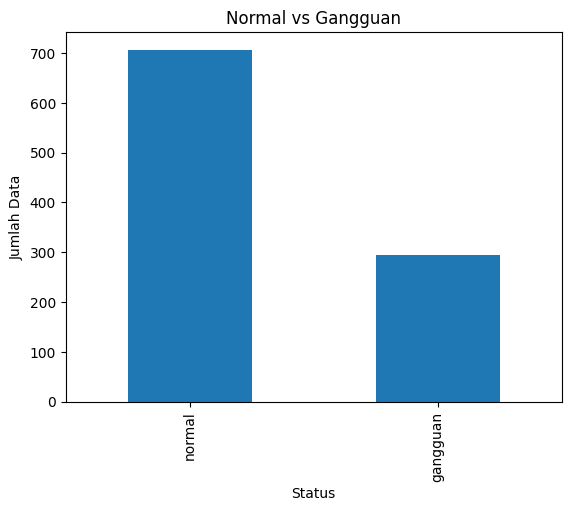

In [16]:
df['status'].value_counts().plot(kind='bar')

plt.title('Normal vs Gangguan')

plt.xlabel('Status')

plt.ylabel('Jumlah Data')

plt.show()

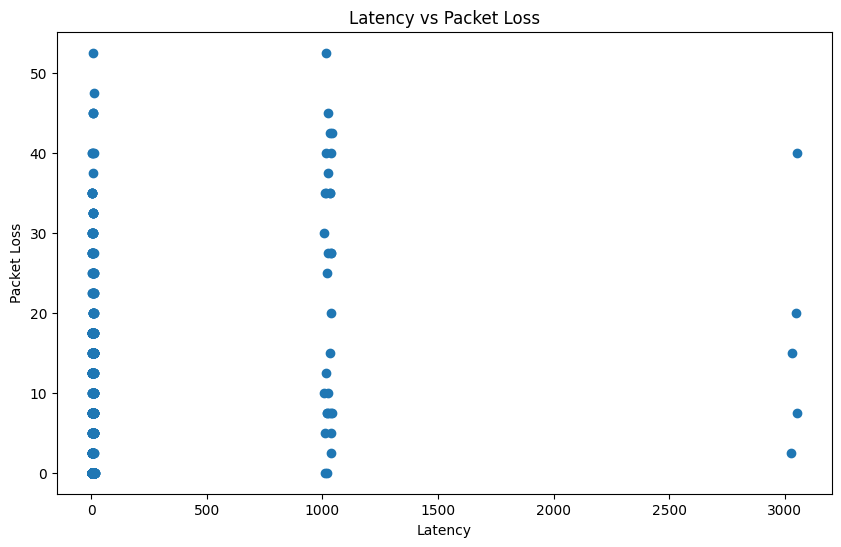

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['latency'],
    df['packet_loss']
)

plt.xlabel('Latency')
plt.ylabel('Packet Loss')

plt.title('Latency vs Packet Loss')

plt.show()